In [ ]:
# ── Install any missing packages ──────────────────────────────────────────────
!pip install -q torchvision matplotlib tqdm

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hassnainzaidi/human-faces-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-faces-data-set' dataset.
Path to dataset files: /kaggle/input/human-faces-data-set


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
#  HYPERPARAMETERS  ── tweak these to experiment
# ═══════════════════════════════════════════════════════════════════════════════

# ── Data ──────────────────────────────────────────────────────────────────────
   # ← change to your Google Drive path
image_size   = 256      # resize all images to 64×64
channels_img = 3       # RGB
batch_size   = 32

# ── Diffusion schedule ────────────────────────────────────────────────────────
T            = 1000    # total timesteps
beta_start   = 1e-4   # β₁  (noise at t=1, very small)
beta_end     = 0.02   # βT  (noise at t=T, larger)

# ── U-Net model ───────────────────────────────────────────────────────────────
model_dim    = 64      # base channel width; deeper = more capacity
time_emb_dim = 256     # sinusoidal time embedding size

# ── Training ──────────────────────────────────────────────────────────────────
num_epochs   = 50      # increase for better quality (100–200 recommended)
lr           = 2e-4

# ── Visualization ─────────────────────────────────────────────────────────────
noise_vis_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999]
#   ^ Which timesteps to display in the forward-noising strip

NUM_GEN_IMAGES = 6     # ← SET THIS (1–10) to control how many faces to generate
assert 1 <= NUM_GEN_IMAGES <= 10, "Keep NUM_GEN_IMAGES between 1 and 10!"

print("Configuration loaded ✅")
print(f"  image_size={image_size}, T={T}, epochs={num_epochs}, batch={batch_size}")
print(f"  Will generate {NUM_GEN_IMAGES} images after training")

Configuration loaded ✅
  image_size=256, T=1000, epochs=50, batch=32
  Will generate 6 images after training


In [ ]:
# ── Transform: resize → tensor → normalize to [-1, 1] ────────────────────────
#   Normalization: (pixel - 0.5) / 0.5  maps [0,1] → [-1,1]
#   This matches the DDPM convention where x₀ ∈ [-1, 1]
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5 for _ in range(channels_img)],
        [0.5 for _ in range(channels_img)]
    )
])

# ── Load dataset (ImageFolder expects subfolders = class names) ───────────────
dataset = datasets.ImageFolder(
    root=path + "/Human Faces",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,      # parallel data loading
    pin_memory=True     # faster GPU transfers
)

print(f"Classes : {dataset.classes}")
print(f"Total   : {len(dataset)} images")
print(f"Batches : {len(loader)} per epoch")

Classes : ['AI-Generated Images', 'Real Images']
Total   : 9630 images
Batches : 301 per epoch


In [ ]:
class DiffusionSchedule:
    """
    Pre-computes all α, ᾱ (alpha-bar), β values for the linear noise schedule.

    Key equations (DDPM, Ho et al. 2020):
      β_t  : noise variance at step t  (linearly increases β_start → β_end)
      α_t  = 1 - β_t
      ᾱ_t  = ∏ α_s for s=1..t      (cumulative product)

    Forward process (closed-form, no loop needed):
      q(x_t | x_0) = N(√ᾱ_t · x_0,  (1-ᾱ_t)·I)
      → x_t = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε,   ε ~ N(0,I)
    """

    def __init__(self, T, beta_start, beta_end, device):
        self.T      = T
        self.device = device

        # Linear schedule: β increases from beta_start to beta_end
        self.betas  = torch.linspace(beta_start, beta_end, T).to(device)  # [T]

        # α_t = 1 - β_t
        self.alphas = 1.0 - self.betas                                     # [T]

        # ᾱ_t = cumulative product of α
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)                 # [T]

        # Pre-compute √ᾱ and √(1-ᾱ) for fast sampling
        self.sqrt_alpha_bar       = torch.sqrt(self.alpha_bar)             # [T]
        self.sqrt_one_minus_alpha = torch.sqrt(1.0 - self.alpha_bar)      # [T]

    def q_sample(self, x0, t):
        """
        Forward diffusion: sample x_t given x_0 and timestep t.

        Args:
            x0 : clean image tensor [B, C, H, W]
            t  : integer timestep tensor [B]  (0-indexed)
        Returns:
            x_t   : noisy image at step t
            noise : the Gaussian noise ε that was added
        """
        noise = torch.randn_like(x0)                             # ε ~ N(0,I)

        # Gather per-sample coefficients, reshape for broadcasting [B,1,1,1]
        sqrt_ab  = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_1ab = self.sqrt_one_minus_alpha[t].view(-1, 1, 1, 1)

        x_t = sqrt_ab * x0 + sqrt_1ab * noise                   # reparameterization
        return x_t, noise


# ── Instantiate schedule ──────────────────────────────────────────────────────
schedule = DiffusionSchedule(T, beta_start, beta_end, device)
print(f"Schedule created: T={T}, β ∈ [{beta_start}, {beta_end}]")
print(f"  ᾱ at t=0   : {schedule.alpha_bar[0].item():.4f}  (≈1, almost no noise)")
print(f"  ᾱ at t=500 : {schedule.alpha_bar[499].item():.4f}")
print(f"  ᾱ at t=999 : {schedule.alpha_bar[999].item():.4f}  (≈0, pure noise)")

Schedule created: T=1000, β ∈ [0.0001, 0.02]
  ᾱ at t=0   : 0.9999  (≈1, almost no noise)
  ᾱ at t=500 : 0.0786
  ᾱ at t=999 : 0.0000  (≈0, pure noise)


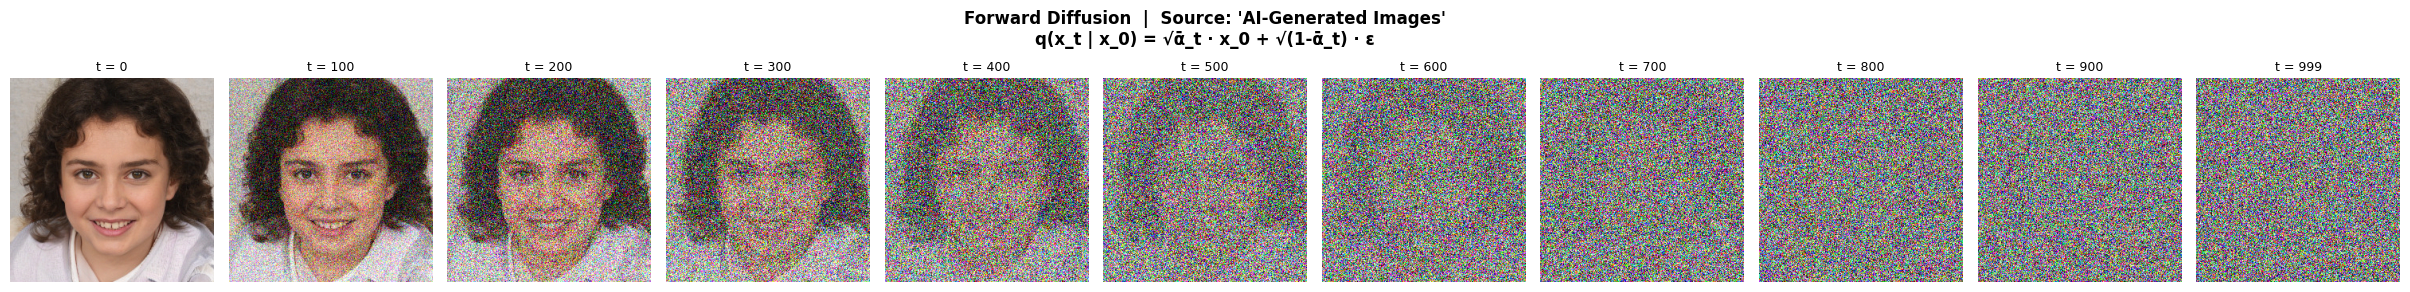

✅ Forward process saved as 'forward_process.png'


In [ ]:
def show_forward_process(schedule, dataset, vis_steps, device):
    """
    Picks one random face image and visualizes how noise accumulates
    across several timesteps via the closed-form forward process.
    """
    # ── Pick a random sample ──────────────────────────────────────────────────
    idx   = random.randint(0, len(dataset) - 1)
    x0, label = dataset[idx]                    # x0 ∈ [-1,1]
    x0    = x0.unsqueeze(0).to(device)          # [1, C, H, W]

    class_name = dataset.classes[label]

    # ── Generate noisy versions at each requested timestep ────────────────────
    fig, axes = plt.subplots(1, len(vis_steps), figsize=(2.2 * len(vis_steps), 3))
    fig.suptitle(
        f"Forward Diffusion  |  Source: '{class_name}'\n"
        "q(x_t | x_0) = √ᾱ_t · x_0 + √(1-ᾱ_t) · ε",
        fontsize=12, fontweight="bold"
    )

    for ax, t_val in zip(axes, vis_steps):
        t_tensor = torch.tensor([t_val], device=device)
        x_t, _   = schedule.q_sample(x0, t_tensor)      # closed-form sampling

        # Convert [-1,1] → [0,1] for display
        img = (x_t.squeeze().cpu().clamp(-1, 1) + 1) / 2
        img = img.permute(1, 2, 0).numpy()               # [H, W, C]

        ax.imshow(img)
        ax.set_title(f"t = {t_val}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("forward_process.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Forward process saved as 'forward_process.png'")


# ── Run visualization ─────────────────────────────────────────────────────────
show_forward_process(schedule, dataset, noise_vis_steps, device)

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
#  BUILDING BLOCKS
# ──────────────────────────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    """
    Encodes scalar timestep t into a high-dimensional vector so the U-Net
    knows *when* in the diffusion process it is.

    Uses the same positional encoding as Transformers:
      PE(t, 2i)   = sin(t / 10000^(2i/d))
      PE(t, 2i+1) = cos(t / 10000^(2i/d))
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        # Linear projection after sinusoidal embedding
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),              # Swish activation (smooth, works well here)
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t):
        # t: [B] integer timesteps
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / half
        )                                                    # [dim/2]
        args  = t[:, None].float() * freqs[None, :]         # [B, dim/2]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1) # [B, dim]
        return self.proj(emb)                                # [B, dim]


class ResBlock(nn.Module):
    """
    Residual block with time-step conditioning.
    Injects time embedding via an affine transform (scale + shift)
    applied after GroupNorm — similar to AdaGN in Improved DDPM.
    """
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        # Main convolution path
        self.conv1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        # Time projection: produces (scale, shift) for each channel
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch * 2)   # *2 for scale and shift
        )
        self.conv2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        # Skip connection (1×1 conv if channels differ)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)                                    # [B, out_ch, H, W]

        # Time conditioning: affine scale + shift
        t_out = self.time_mlp(t_emb)                         # [B, out_ch*2]
        scale, shift = t_out.chunk(2, dim=-1)                # each [B, out_ch]
        h = h * (1 + scale[:, :, None, None]) + shift[:, :, None, None]

        h = self.conv2(h)
        return h + self.skip(x)                              # residual


class DownBlock(nn.Module):
    """ResBlock + 2× spatial downsampling via strided conv."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.res    = ResBlock(in_ch, out_ch, time_dim)
        self.down   = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)  # halves H,W

    def forward(self, x, t_emb):
        skip = self.res(x, t_emb)     # store for skip connection
        x    = self.down(skip)
        return x, skip                # return (downsampled, skip)


class UpBlock(nn.Module):
    """2× upsample + concatenate skip + ResBlock."""
    def __init__(self, in_ch, out_ch, skip_ch, time_dim):
        super().__init__()
        self.up  = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1)
        # Dynamically calculate channels: upsampled output + skip input
        self.res = ResBlock(out_ch + skip_ch, out_ch, time_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)                         # 2× spatial upsample
        x = torch.cat([x, skip], dim=1)        # concatenate encoder skip
        return self.res(x, t_emb)


# ──────────────────────────────────────────────────────────────────────────────
#  U-NET
# ──────────────────────────────────────────────────────────────────────────────

class UNet(nn.Module):
    """
    U-Net that predicts the noise ε added at each diffusion step.

    Architecture (for image_size=64, model_dim=64):
      Input  64×64×3
      ↓ Down1 → 32×32×64
      ↓ Down2 → 16×16×128
      ↓ Down3 → 8×8×256
      Bottleneck 8×8×256
      ↑ Up3   → 16×16×128
      ↑ Up2   → 32×32×64
      ↑ Up1   → 64×64×64
      Output 64×64×3
    """
    def __init__(self, img_ch, model_dim, time_emb_dim):
        super().__init__()

        # Sinusoidal time embedding
        self.time_emb = SinusoidalTimeEmbedding(time_emb_dim)

        # Initial projection: 3 → model_dim
        self.init_conv = nn.Conv2d(img_ch, model_dim, 3, padding=1)

        # ── Encoder (3 downsampling stages) ───────────────────────────────────
        self.down1 = DownBlock(model_dim,     model_dim * 2, time_emb_dim)
        self.down2 = DownBlock(model_dim * 2, model_dim * 4, time_emb_dim)
        self.down3 = DownBlock(model_dim * 4, model_dim * 4, time_emb_dim)

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.bottleneck = nn.Sequential(
            ResBlock(model_dim * 4, model_dim * 4, time_emb_dim),
            ResBlock(model_dim * 4, model_dim * 4, time_emb_dim),
        )

        # ── Decoder (3 upsampling stages) ─────────────────────────────────────
        # UpBlock(in_ch, out_ch, skip_ch, time_dim)
        self.up3 = UpBlock(model_dim * 4, model_dim * 4, model_dim * 4, time_emb_dim) # skip s3 is 256
        self.up2 = UpBlock(model_dim * 4, model_dim * 2, model_dim * 4, time_emb_dim) # skip s2 is 256
        self.up1 = UpBlock(model_dim * 2, model_dim,     model_dim * 2, time_emb_dim) # skip s1 is 128

        # ── Output projection: model_dim → img_ch ─────────────────────────────
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, model_dim),
            nn.SiLU(),
            nn.Conv2d(model_dim, img_ch, 1)   # 1×1 conv for final projection
        )

    def forward(self, x, t):
        """
        Args:
            x : noisy image [B, C, H, W]
            t : timestep    [B]
        Returns:
            predicted noise ε_θ(x_t, t)  [B, C, H, W]
        """
        # ── Time embedding ────────────────────────────────────────────────────
        t_emb = self.time_emb(t)          # [B, time_emb_dim]

        # ── Encoder ───────────────────────────────────────────────────────────
        x  = self.init_conv(x)            # [B, D,  64, 64]
        x, s1 = self.down1(x, t_emb)     # [B, 2D, 32, 32],  skip s1
        x, s2 = self.down2(x, t_emb)     # [B, 4D, 16, 16],  skip s2
        x, s3 = self.down3(x, t_emb)     # [B, 4D,  8,  8],  skip s3

        # ── Bottleneck ────────────────────────────────────────────────────────
        # ResBlocks don't use t_emb via the Sequential wrapper, call manually
        for block in self.bottleneck:
            x = block(x, t_emb)          # [B, 4D, 8, 8]

        # ── Decoder ───────────────────────────────────────────────────────────
        x = self.up3(x, s3, t_emb)       # [B, 4D, 16, 16]
        x = self.up2(x, s2, t_emb)       # [B, 2D, 32, 32]
        x = self.up1(x, s1, t_emb)       # [B, D,  64, 64]

        return self.out_conv(x)           # [B, 3,  64, 64]  ← predicted ε


# ── Build model ───────────────────────────────────────────────────────────────
model = UNet(channels_img, model_dim, time_emb_dim).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ U-Net built | Parameters: {total_params:,}  ({total_params/1e6:.1f}M)")

✅ U-Net built | Parameters: 12,548,163  (12.5M)


next i think better


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
#  CONSOLIDATED U-NET ARCHITECTURE
# ──────────────────────────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    """Encodes scalar timesteps into vectors of length dim using sine/cosine waves."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args  = t[:, None].float() * freqs[None, :]
        emb   = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.proj(emb)


class UNet(nn.Module):
    """
    A direct, unrolled U-Net. No scattered block classes.
    Follows data sequentially down the encoder, through the bottleneck,
    and up the decoder.
    """
    def __init__(self, img_ch=3, model_dim=64, time_emb_dim=256):
        super().__init__()

        # 1. Time Awareness Signature
        self.time_emb = SinusoidalTimeEmbedding(time_emb_dim)

        # 2. Base Dimensions Mapping
        D1, D2, D4 = model_dim, model_dim * 2, model_dim * 4  # 64, 128, 256

        # --- ENCODER PATH (Downsampling) ---
        self.init_conv = nn.Conv2d(img_ch, D1, kernel_size=3, padding=1)

        # Downstage 1: 64x64x64 -> 32x32x128
        self.enc1_conv1 = nn.Conv2d(D1, D2, kernel_size=3, padding=1)
        self.enc1_time  = nn.Linear(time_emb_dim, D2 * 2)
        self.enc1_conv2 = nn.Conv2d(D2, D2, kernel_size=3, padding=1)
        self.enc1_skip  = nn.Conv2d(D1, D2, kernel_size=1)
        self.down1      = nn.Conv2d(D2, D2, kernel_size=4, stride=2, padding=1)

        # Downstage 2: 32x32x128 -> 16x16x256
        self.enc2_conv1 = nn.Conv2d(D2, D4, kernel_size=3, padding=1)
        self.enc2_time  = nn.Linear(time_emb_dim, D4 * 2)
        self.enc2_conv2 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)
        self.enc2_skip  = nn.Conv2d(D2, D4, kernel_size=1)
        self.down2      = nn.Conv2d(D4, D4, kernel_size=4, stride=2, padding=1)

        # Downstage 3: 16x16x256 -> 8x8x256
        self.enc3_conv1 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)
        self.enc3_time  = nn.Linear(time_emb_dim, D4 * 2)
        self.enc3_conv2 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)
        self.down3      = nn.Conv2d(D4, D4, kernel_size=4, stride=2, padding=1)

        # --- BOTTLENECK PATH (Deep Processing at 8x8) ---
        self.btl_conv1 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)
        self.btl_time1 = nn.Linear(time_emb_dim, D4 * 2)
        self.btl_conv2 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)

        # --- DECODER PATH (Upssampling & Merging Skips) ---
        # Upstage 3: 8x8x256 -> 16x16x256  || Combines with s3 (256 channels)
        self.up3        = nn.ConvTranspose2d(D4, D4, kernel_size=4, stride=2, padding=1)
        self.dec3_conv1 = nn.Conv2d(D4 + D4, D4, kernel_size=3, padding=1) # 256 + 256 = 512 in
        self.dec3_time  = nn.Linear(time_emb_dim, D4 * 2)
        self.dec3_conv2 = nn.Conv2d(D4, D4, kernel_size=3, padding=1)
        self.dec3_skip  = nn.Conv2d(D4 + D4, D4, kernel_size=1)

        # Upstage 2: 16x16x256 -> 32x32x128 || Combines with s2 (256 channels)
        self.up2        = nn.ConvTranspose2d(D4, D2, kernel_size=4, stride=2, padding=1)
        self.dec2_conv1 = nn.Conv2d(D2 + D4, D2, kernel_size=3, padding=1) # 128 + 256 = 384 in
        self.dec2_time  = nn.Linear(time_emb_dim, D2 * 2)
        self.dec2_conv2 = nn.Conv2d(D2, D2, kernel_size=3, padding=1)
        self.dec2_skip  = nn.Conv2d(D2 + D4, D2, kernel_size=1)

        # Upstage 1: 32x32x128 -> 64x64x64  || Combines with s1 (128 channels)
        self.up1        = nn.ConvTranspose2d(D2, D1, kernel_size=4, stride=2, padding=1)
        self.dec1_conv1 = nn.Conv2d(D1 + D2, D1, kernel_size=3, padding=1) # 64 + 128 = 192 in
        self.dec1_time  = nn.Linear(time_emb_dim, D1 * 2)
        self.dec1_conv2 = nn.Conv2d(D1, D1, kernel_size=3, padding=1)
        self.dec1_skip  = nn.Conv2d(D1 + D2, D1, kernel_size=1)

        # --- FINAL PROJECTION BACK TO RGB IMAGE ---
        self.out_norm = nn.GroupNorm(8, D1)
        self.out_conv = nn.Conv2d(D1, img_ch, kernel_size=1)

    def _apply_time(self, x, t_emb, time_layer):
        """Helper to compute scale/shift affine values and inject into channels."""
        t_out = time_layer(F.silu(t_emb))
        scale, shift = t_out.chunk(2, dim=-1)
        return x * (1 + scale[:, :, None, None]) + shift[:, :, None, None]

    def forward(self, x, t):
        # Generate the high-dimensional timeline signature
        t_emb = self.time_emb(t)

        # ----------------------------------------------------------------------
        #  ENCODER PATH (Save structural features at each resolution)
        # ----------------------------------------------------------------------
        x = self.init_conv(x)

        # Downstage 1: Process at 64x64, save s1, downsample to 32x32
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.enc1_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.enc1_time)
        h = self.enc1_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h)))
        s1 = h + self.enc1_skip(x) # s1 shape: [B, 128, 64, 64]
        x = self.down1(s1)         # x shape:  [B, 128, 32, 32]

        # Downstage 2: Process at 32x32, save s2, downsample to 16x16
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.enc2_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.enc2_time)
        h = self.enc2_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h)))
        s2 = h + self.enc2_skip(x) # s2 shape: [B, 256, 32, 32]
        x = self.down2(s2)         # x shape:  [B, 256, 16, 16]

        # Downstage 3: Process at 16x16, save s3, downsample to 8x8
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.enc3_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.enc3_time)
        s3 = self.enc3_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h))) # identity skip (D4->D4)
        x = self.down3(s3)         # x shape:  [B, 256, 8, 8]

        # ----------------------------------------------------------------------
        #  BOTTLENECK PATH (Deepest bottleneck space)
        # ----------------------------------------------------------------------
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.btl_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.btl_time1)
        x = self.btl_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h))) + x

        # ----------------------------------------------------------------------
        #  DECODER PATH (Upsample, glue skip copies together, clean up)
        # ----------------------------------------------------------------------
        # Upstage 3: Blow up to 16x16, glue s3, process
        x = self.up3(x)
        x = torch.cat([x, s3], dim=1) # Merges 256 + 256 -> 512 channels
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.dec3_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.dec3_time)
        h = self.dec3_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h)))
        x = h + self.dec3_skip(x)

        # Upstage 2: Blow up to 32x32, glue s2, process
        x = self.up2(x)
        x = torch.cat([x, s2], dim=1) # Merges 128 + 256 -> 384 channels
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.dec2_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.dec2_time)
        h = self.dec2_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h)))
        x = h + self.dec2_skip(x)

        # Upstage 1: Blow up to 64x64, glue s1, process
        x = self.up1(x)
        x = torch.cat([x, s1], dim=1) # Merges 64 + 128 -> 192 channels
        h = nn.GroupNorm(8, x.shape[1]).to(x.device)(x)
        h = self.dec1_conv1(F.silu(h))
        h = self._apply_time(h, t_emb, self.dec1_time)
        h = self.dec1_conv2(F.silu(nn.GroupNorm(8, h.shape[1]).to(x.device)(h)))
        x = h + self.dec1_skip(x)

        # ----------------------------------------------------------------------
        #  FINAL OUTPUT (Map 64 channels back to 3 RGB Image channels)
        # ----------------------------------------------------------------------
        return self.out_conv(F.silu(self.out_norm(x)))

# ── Build model ───────────────────────────────────────────────────────────────
model = UNet(channels_img, model_dim, time_emb_dim).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Consolidated U-Net built | Parameters: {total_params:,}  ({total_params/1e6:.1f}M)")

In [ ]:
# ── Optimizer & loss ──────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# MSE between predicted noise and actual noise (simple DDPM loss)
loss_fn   = nn.MSELoss()

# ── Learning rate scheduler (cosine decay) ────────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-6
)

# ── Training ──────────────────────────────────────────────────────────────────
loss_history = []

for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{num_epochs}", leave=False)
    for x0, _ in pbar:
        x0 = x0.to(device)                           # clean images [B, 3, 64, 64]

        # ── Sample random timesteps for each image in the batch ───────────────
        # Each image in the batch gets a DIFFERENT random t → diverse gradients
        t  = torch.randint(0, T, (x0.size(0),), device=device)  # [B]

        # ── Forward diffusion: add noise ──────────────────────────────────────
        x_t, noise = schedule.q_sample(x0, t)        # x_t & ε (ground truth)

        # ── Predict noise with U-Net ──────────────────────────────────────────
        noise_pred = model(x_t, t)                    # ε_θ(x_t, t)

        # ── DDPM loss: L = E[||ε - ε_θ(x_t, t)||²] ──────────────────────────
        loss = loss_fn(noise_pred, noise)

        # ── Backprop ──────────────────────────────────────────────────────────
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs}  |  Loss: {avg_loss:.5f}  |  LR: {scheduler.get_last_lr()[0]:.2e}")

# ── Save model weights ────────────────────────────────────────────────────────
torch.save(model.state_dict(), "ddpm_unet.pth")
print("\n✅ Training complete! Weights saved to 'ddpm_unet.pth'")

# ── Plot loss curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color="steelblue", linewidth=1.5)
plt.xlabel("Epoch");  plt.ylabel("MSE Loss");  plt.title("Training Loss")
plt.grid(alpha=0.3);  plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120);  plt.show()

Epoch 1/50:   0%|          | 0/301 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 768.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 663.81 MiB is free. Including non-PyTorch memory, this process has 13.91 GiB memory in use. Of the allocated memory 13.47 GiB is allocated by PyTorch, and 321.73 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
@torch.no_grad()
def ddpm_sample(model, schedule, shape, device, capture_every=100):
    """
    Generates images from pure noise using the reverse diffusion process.

    Reverse step (DDPM):
      x_{t-1} = (1/√α_t) · (x_t - (β_t/√(1-ᾱ_t)) · ε_θ(x_t,t))  + σ_t·z

    Where:
      ε_θ  : U-Net noise prediction
      σ_t  : √β_t  (standard DDPM posterior std)
      z    : random Gaussian noise (0 at t=0, i.e. final step)

    Args:
        model        : trained U-Net
        schedule     : DiffusionSchedule
        shape        : (B, C, H, W) — number and size of images to generate
        device       : torch device
        capture_every: save intermediate frames every N steps (for animation)
    Returns:
        x0       : final generated images [B, C, H, W]
        snapshots: list of [B, C, H, W] tensors at various t values
    """
    model.eval()

    # ── Start from pure Gaussian noise xT ─────────────────────────────────────
    x = torch.randn(shape, device=device)   # xT ~ N(0, I)

    snapshots = []   # intermediate frames for visualization

    # ── Iterative denoising: T → T-1 → ... → 0 ───────────────────────────────
    for t_val in tqdm(reversed(range(schedule.T)), desc="Sampling", total=schedule.T):
        t_batch = torch.full((shape[0],), t_val, device=device, dtype=torch.long)

        # Predict noise with U-Net
        eps_pred = model(x, t_batch)                             # ε_θ(x_t, t)

        # Extract schedule values for step t
        alpha_t     = schedule.alphas[t_val]                     # α_t
        alpha_bar_t = schedule.alpha_bar[t_val]                  # ᾱ_t
        beta_t      = schedule.betas[t_val]                      # β_t

        # Compute mean of posterior q(x_{t-1} | x_t, x_0)
        coef        = beta_t / torch.sqrt(1.0 - alpha_bar_t)
        mean        = (1.0 / torch.sqrt(alpha_t)) * (x - coef * eps_pred)

        # Add stochastic noise (except at final step t=0)
        if t_val > 0:
            z = torch.randn_like(x)                              # z ~ N(0,I)
            x = mean + torch.sqrt(beta_t) * z                   # x_{t-1}
        else:
            x = mean                                             # final x_0 (no noise)

        # Capture snapshot for visualization
        if t_val % capture_every == 0 or t_val == schedule.T - 1:
            snapshots.append((t_val, x.clone().cpu()))

    return x.cpu(), snapshots

print("Sampling function defined ✅")

In [ ]:
# ── Generate ONE image and watch it denoise step-by-step ─────────────────────
print("Running reverse diffusion for denoising visualization (1 image)...")

_, snapshots = ddpm_sample(
    model, schedule,
    shape=(1, channels_img, image_size, image_size),
    device=device,
    capture_every=100    # save frame every 100 steps
)

# ── Plot the denoising trajectory ─────────────────────────────────────────────
n_snaps = len(snapshots)
fig, axes = plt.subplots(1, n_snaps, figsize=(2.2 * n_snaps, 3))
fig.suptitle(
    "Reverse Denoising Process  |  xT → x₀\n"
    "p_θ(x_{t-1}|x_t) = N(μ_θ(x_t,t), σ_t²I)",
    fontsize=11, fontweight="bold"
)

for ax, (t_val, img_tensor) in zip(axes, snapshots):
    img = (img_tensor.squeeze().clamp(-1, 1) + 1) / 2  # → [0,1]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"t = {t_val}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("denoising_process.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Denoising trajectory saved as 'denoising_process.png'")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  ↓↓↓  CHANGE THIS NUMBER  ↓↓↓
# ══════════════════════════════════════════════════════════════════════════════
NUM_GEN_IMAGES = 10    # ← set any value from 1 to 10
# ══════════════════════════════════════════════════════════════════════════════

assert 1 <= NUM_GEN_IMAGES <= 10, "Please keep NUM_GEN_IMAGES between 1 and 10"

print(f"Generating {NUM_GEN_IMAGES} face(s) from pure noise...")
print("This runs the full T=1000 reverse chain — grab a coffee ☕")

# ── Run reverse diffusion ─────────────────────────────────────────────────────
generated, _ = ddpm_sample(
    model, schedule,
    shape=(NUM_GEN_IMAGES, channels_img, image_size, image_size),
    device=device,
    capture_every=9999  # don't capture intermediates (faster)
)

# ── Display generated images ──────────────────────────────────────────────────
ncols = min(NUM_GEN_IMAGES, 5)         # max 5 per row
nrows = math.ceil(NUM_GEN_IMAGES / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.array(axes).reshape(-1)      # flatten for easy indexing

fig.suptitle(
    f"🧠 DDPM Generated Faces  ({NUM_GEN_IMAGES} images)\n"
    "Started from pure Gaussian noise xT ~ N(0,I)",
    fontsize=12, fontweight="bold"
)

for i, ax in enumerate(axes):
    if i < NUM_GEN_IMAGES:
        img = (generated[i].clamp(-1, 1) + 1) / 2   # → [0,1]
        img = img.permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(f"Generated #{i+1}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("generated_faces.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Generated faces saved as 'generated_faces.png'")

In [ ]:
from glob import glob
glob("/content/*")

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import shutil

save_dir = path + "/DDPM_Results"
os.makedirs(save_dir, exist_ok=True)

files_to_save = [
    "ddpm_unet.pth",
    "forward_process.png",
    "denoising_process.png",
    "generated_faces.png",
    "loss_curve.png",
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, save_dir)
        print(f"  Copied {f} → {save_dir}")

print("\n✅ All results saved to Google Drive!")